# Physics-Informed Neural Network (PINN) for Burger's Equation

This project implements a Physics-Informed Neural Network (PINN) to solve the 1D **viscous Burger's equation** using PyTorch.

## Problem Statement

We aim to solve the nonlinear PDE:

\begin{equation*}
	u_t + u\,u_x = \nu\,u_{xx}
\end{equation*}


with:

- Domain: 

\begin{equation*}
	x \in [-1, 1], \quad t \in [0, 1]
\end{equation*}
 
- Initial condition: 

\begin{equation*}
	u(x, 0) = -\sin(\pi x)
\end{equation*}
- Boundary condition: 

\begin{equation*}
	u(-1, t) = u(1, t) = 0
\end{equation*}

---


In [2]:
import torch
import torch.nn as nn
import numpy as np  
import matplotlib.pyplot as plt

In [3]:
# ---------------------------------------
# 1. Define the PINN Model
# ---------------------------------------
class PINN2D(nn.Module):
    def __init__(self, layers):
        super(PINN2D, self).__init__()
        self.net = nn.Sequential(
            *[nn.Sequential(nn.Linear(layers[i], layers[i+1]), nn.Tanh()) for i in range(len(layers)-2)],
            nn.Linear(layers[-2], layers[-1])
        )

    def forward(self, t, x, y):
        input = torch.cat([t, x, y], dim=1)
        return self.net(input)  # Output: [u, v]

2D **viscous Burgers' equations**
\begin{equation*}
	\begin{aligned}
		u_t + u\,u_x + v\,u_y &= \nu \left( u_{xx} + u_{yy} \right), \\
		v_t + u\,v_x + v\,v_y &= \nu \left( v_{xx} + v_{yy} \right),
	\end{aligned}
\end{equation*}


In [4]:
# ---------------------------------------
# 2. PDE Residuals
# ---------------------------------------
def pde_residual(model, t, x, y, nu):
    u_v = model(t, x, y)
    u, v = u_v[:, 0:1], u_v[:, 1:2]

    grads = lambda f, inputs: torch.autograd.grad(f, inputs, grad_outputs=torch.ones_like(f),
                                                  retain_graph=True, create_graph=True)[0]

    u_t = grads(u, t)
    u_x = grads(u, x)
    u_y = grads(u, y)
    u_xx = grads(u_x, x)
    u_yy = grads(u_y, y)

    v_t = grads(v, t)
    v_x = grads(v, x)
    v_y = grads(v, y)
    v_xx = grads(v_x, x)
    v_yy = grads(v_y, y)

    f_u = u_t + u * u_x + v * u_y - nu * (u_xx + u_yy)
    f_v = v_t + u * v_x + v * v_y - nu * (v_xx + v_yy)

    return f_u, f_v

In [5]:
# ---------------------------------------
# 3. Generate Data (initial + boundary + collocation)
# ---------------------------------------
def generate_data(N_f=10000, N_ic=100, N_bc=100):
    x_min, x_max = -1, 1
    y_min, y_max = -1, 1
    t_min, t_max = 0, 1

    # Interior points
    x_f = torch.rand(N_f, 1) * (x_max - x_min) + x_min
    y_f = torch.rand(N_f, 1) * (y_max - y_min) + y_min
    t_f = torch.rand(N_f, 1) * (t_max - t_min) + t_min

    # Initial condition at t=0
    x_ic = torch.linspace(x_min, x_max, N_ic).reshape(-1, 1)
    y_ic = torch.linspace(y_min, y_max, N_ic).reshape(-1, 1)
    x_ic, y_ic = torch.meshgrid(x_ic.squeeze(), y_ic.squeeze(), indexing='ij')
    x_ic, y_ic = x_ic.reshape(-1,1), y_ic.reshape(-1,1)
    t_ic = torch.zeros_like(x_ic)
    u_ic = -torch.sin(np.pi * x_ic) * torch.sin(np.pi * y_ic)
    v_ic = torch.zeros_like(u_ic)

    # Boundary conditions (assume u = v = 0 at all boundaries)
    t_bc = torch.linspace(t_min, t_max, N_bc).reshape(-1, 1)
    xy_bc = torch.linspace(x_min, x_max, N_bc).reshape(-1, 1)

    # 4 boundaries (x=±1, y=±1)
    x_b1 = -1 * torch.ones_like(xy_bc)
    x_b2 = 1 * torch.ones_like(xy_bc)
    y_b1 = -1 * torch.ones_like(xy_bc)
    y_b2 = 1 * torch.ones_like(xy_bc)

    x_bc = torch.cat([x_b1, x_b2, xy_bc, xy_bc])
    y_bc = torch.cat([xy_bc, xy_bc, y_b1, y_b2])
    t_bc = torch.cat([t_bc]*4)
    u_bc = torch.zeros_like(x_bc)
    v_bc = torch.zeros_like(y_bc)

    return t_f, x_f, y_f, t_ic, x_ic, y_ic, u_ic, v_ic, t_bc, x_bc, y_bc, u_bc, v_bc

In [6]:
# ---------------------------------------
# 4. Loss Functions
# ---------------------------------------
def loss_pde(model, t_f, x_f, y_f, nu):
    f_u, f_v = pde_residual(model, t_f, x_f, y_f, nu)
    return torch.mean(f_u**2 + f_v**2)

def loss_ic(model, t_ic, x_ic, y_ic, u_ic, v_ic):
    pred = model(t_ic, x_ic, y_ic)
    u_pred, v_pred = pred[:, 0:1], pred[:, 1:2]
    return torch.mean((u_pred - u_ic)**2 + (v_pred - v_ic)**2)

def loss_bc(model, t_bc, x_bc, y_bc, u_bc, v_bc):
    pred = model(t_bc, x_bc, y_bc)
    u_pred, v_pred = pred[:, 0:1], pred[:, 1:2]
    return torch.mean((u_pred - u_bc)**2 + (v_pred - v_bc)**2)

In [7]:
# ---------------------------------------
# 5. Training
# ---------------------------------------
layers = [3, 64, 64, 64, 64, 2]  # Input: (t,x,y), Output: (u,v)
model = PINN2D(layers)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
nu = 0.01 / np.pi

# Generate data
t_f, x_f, y_f, t_ic, x_ic, y_ic, u_ic, v_ic, t_bc, x_bc, y_bc, u_bc, v_bc = generate_data()

# Enable autograd
t_f.requires_grad = x_f.requires_grad = y_f.requires_grad = True

# Training loop
epochs = 3000
for epoch in range(epochs):
    optimizer.zero_grad()
    loss = (
        loss_pde(model, t_f, x_f, y_f, nu)
        + loss_ic(model, t_ic, x_ic, y_ic, u_ic, v_ic)
        + loss_bc(model, t_bc, x_bc, y_bc, u_bc, v_bc)
    )
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 0.259496
Epoch 500, Loss: 0.045277
Epoch 1000, Loss: 0.031394
Epoch 1500, Loss: 0.027189
Epoch 2000, Loss: 0.024605
Epoch 2500, Loss: 0.023419


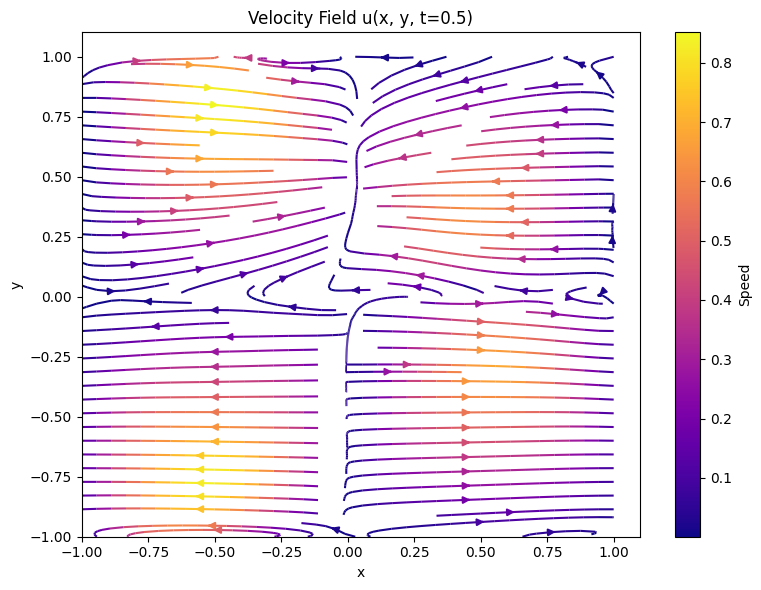

In [8]:
# ---------------------------------------
# 6. Visualization
# ---------------------------------------
model.eval()
x_vis = torch.linspace(-1, 1, 100)
y_vis = torch.linspace(-1, 1, 100)
X, Y = torch.meshgrid(x_vis, y_vis, indexing='ij')
T = torch.ones_like(X) * 0.5  # Snapshot at t = 0.5

t_flat = T.reshape(-1, 1)
x_flat = X.reshape(-1, 1)
y_flat = Y.reshape(-1, 1)

with torch.no_grad():
    pred = model(t_flat, x_flat, y_flat)
    U = pred[:, 0].reshape(100, 100).numpy()
    V = pred[:, 1].reshape(100, 100).numpy()

plt.figure(figsize=(8,6))
plt.streamplot(x_vis.numpy(), y_vis.numpy(), U.T, V.T, color=np.sqrt(U**2 + V**2), cmap='plasma', density=1.2)
plt.title("Velocity Field u(x, y, t=0.5)")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar(label='Speed')
plt.tight_layout()
plt.show()